# Chapter 4: NumPy Basics: Arrays and Vectorized Computation

- Practical tools like `pandas` rely on `NumPy`.
- `NumPy` is very fast at handling arrays (vectors).

In [298]:
# Load numpy
import numpy as np

## The NumPy `ndarray`: A Multidimensional Array Object

The N-dimensional array facilitates creation of higher dimensional data containers (e.g. matrices) that can be operated on for entire objects at once.

In [299]:
# Create 2D array
data = np.array([[1.5, -0.1, 3], [0, -3, 6.5]])

In [300]:
# Operate on array
data * 5.5

array([[  8.25,  -0.55,  16.5 ],
       [  0.  , -16.5 ,  35.75]])

All arrays have dimensionality (shape) and one data type across the array.

In [301]:
print(data.shape)
print(data.dtype)

(2, 3)
float64


### Creating ndarrays

When arrays are created using nested lists, dimensionality is inferred outside in (dim 1 = outermost list dimension, dim 2 = next inner list dimension, dim 3 = next inner list dimension, etc.)

In [302]:
# Create a 3D array
arr = np.array(
    [
        [[1, 2, 3], [4, 5, 6], [7, 8, 9], [10, 11, 12]],
        [[13, 14, 15], [16, 17, 18], [19, 20, 21], [22, 23, 24]],
    ]
)

print(arr.shape)
arr

(2, 4, 3)


array([[[ 1,  2,  3],
        [ 4,  5,  6],
        [ 7,  8,  9],
        [10, 11, 12]],

       [[13, 14, 15],
        [16, 17, 18],
        [19, 20, 21],
        [22, 23, 24]]])

Produce an array containing `0` or `1` using the respective functions, passing dimensions as a tuple.

In [303]:
# Provide dimensionality
np.zeros((10, 2))

array([[0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.]])

In [304]:
# Provide another array to copycat dimensionality from
np.ones_like(arr)

array([[[1, 1, 1],
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]],

       [[1, 1, 1],
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]]])

### Data types

We can specify data types for ndarrays (float, int, signed/unsigned, string, etc.) at point of creation. For now, let Python handle it...

In [305]:
# Force as complex number
arr1 = np.array(
    [
        [[1, 2, 3], [4, 5, 6], [7, 8, 9], [10, 11, 12]],
        [[13, 14, 15], [16, 17, 18], [19, 20, 21], [22, 23, 24]],
    ],
    dtype=np.float64,
)

# Automatic
arr2 = np.array(
    [
        [[1, 2, 3], [4, 5, 6], [7, 8, 9], [10, 11, 12]],
        [[13, 14, 15], [16, 17, 18], [19, 20, 21], [22, 23, 24]],
    ]
)

# Show type
print(arr1.dtype)
print(arr2.dtype)

float64
int64


We can coerce array data type using the `astype` method. Note that `astype` doesn't mutate the original array, functional style.

In [306]:
# Convert arr2 to same dtype as arr1
arr2 = arr2.astype(np.float64)

print(arr2.dtype)

float64


### Arithmetic

Arithmetic operations between equal-size arrays apply it element-wise

In [307]:
arr2 * arr2

array([[[  1.,   4.,   9.],
        [ 16.,  25.,  36.],
        [ 49.,  64.,  81.],
        [100., 121., 144.]],

       [[169., 196., 225.],
        [256., 289., 324.],
        [361., 400., 441.],
        [484., 529., 576.]]])

Arithmetic operations between equal-size array and a scalar recycles the scalar to each element.

In [308]:
arr2 * (1 / 3)

array([[[0.33333333, 0.66666667, 1.        ],
        [1.33333333, 1.66666667, 2.        ],
        [2.33333333, 2.66666667, 3.        ],
        [3.33333333, 3.66666667, 4.        ]],

       [[4.33333333, 4.66666667, 5.        ],
        [5.33333333, 5.66666667, 6.        ],
        [6.33333333, 6.66666667, 7.        ],
        [7.33333333, 7.66666667, 8.        ]]])

Comparisons between equal-size arrays return a boolean array.

In [309]:
arr3 = np.array([[1, 2, 3], [4, 5, 6]])
arr4 = np.array([[6, 5, 4], [3, 2, 1]])

arr3 > arr4

array([[False, False, False],
       [ True,  True,  True]])

### Basic Indexing and Slicing

#### List vs. Array

Arrays can be sliced / subsetted like lists. Unlike lists, the created slices are views connected to the original array. Modifying the slices modify the original array.

In [310]:
# Create a list, mutate slice.
## Create a list
ex_list = list(range(12))

## Create and mutate slice
ex_list_slice = ex_list[5:8]
ex_list_slice[0:2] = 12, 12

## Show list is unchanged
ex_list

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

In [311]:
# Create an array, mutate slice.
## Create array
ex_arr = np.arange(12)

## Create and mutate slice
ex_arr_slice = ex_arr[5:8]
ex_arr_slice[0:2] = 12, 12

## Show array is changed
ex_arr

array([ 0,  1,  2,  3,  4, 12, 12,  7,  8,  9, 10, 11])

#### Multidimensional subsets

Multidimensional arrays are sliced outside-in.

In [312]:
# Example from earlier: arr2
arr2 = np.array(
    [
        [[1, 2, 3], [4, 5, 6], [7, 8, 9], [10, 11, 12]],
        [[13, 14, 15], [16, 17, 18], [19, 20, 21], [22, 23, 24]],
    ]
)

print(arr2)
print(arr2.shape)

[[[ 1  2  3]
  [ 4  5  6]
  [ 7  8  9]
  [10 11 12]]

 [[13 14 15]
  [16 17 18]
  [19 20 21]
  [22 23 24]]]
(2, 4, 3)


In [313]:
# To get the value 12
arr2[0][3][2]

# Or
arr2[0, 3, 2]

np.int64(12)

In [314]:
# To get the last 22, 23, 24 array
arr2[1, 3]

array([22, 23, 24])

In [315]:
# Slice only using ranges to keep dimensionality in the array
arr2[0:1, 1:3, 0:2]

array([[[4, 5],
        [7, 8]]])

In [316]:
# Mix index and slices to reduce dimensionality in the array
arr2[0, 1:3, 0:2]

array([[4, 5],
       [7, 8]])

### Boolean Indexing

This allows for subsetting of an array using a boolean array. Boolean indexing can be mixed with normal indexing and slicing.

In [317]:
# Create example data
names = np.array(["Bob", "Joe", "Will", "Bob", "Will", "Joe", "Joe"])
data = np.array([[4, 7], [0, 2], [-5, 6], [0, 0], [1, 2], [-12, -4], [3, 4]])

In [318]:
# Subset data for everyone with names equal to Joe
data[names == "Joe"]

array([[  0,   2],
       [-12,  -4],
       [  3,   4]])

In [319]:
# Subset data for everyone with names equal to Joe, then grab 2nd index of array
data[names == "Joe", 1]

array([ 2, -4,  4])

In [320]:
# Subset data for everyone with names equal to Joe, then grab 2nd index of array, keeping dimensionality
data[names == "Joe", 1:]

array([[ 2],
       [-4],
       [ 4]])

Boolean indexing and assigning the slice to a variable creates a copy of the data. This is unlike simple indexing.

In [321]:
# Create slice
data_sub = data[names == "Joe", 1:]

In [322]:
# Whole array
data

array([[  4,   7],
       [  0,   2],
       [ -5,   6],
       [  0,   0],
       [  1,   2],
       [-12,  -4],
       [  3,   4]])

In [323]:
# Mutate slice
data_sub[:] = 3

In [324]:
# Show whole array isn't modified
data

array([[  4,   7],
       [  0,   2],
       [ -5,   6],
       [  0,   0],
       [  1,   2],
       [-12,  -4],
       [  3,   4]])

To mutate the array, set values directly.

In [325]:
data[names == "Joe", 1:] = 3
data

array([[  4,   7],
       [  0,   3],
       [ -5,   6],
       [  0,   0],
       [  1,   2],
       [-12,   3],
       [  3,   3]])

### Fancy Indexing

This is indexing using integer arrays. For example, with a 2D array:

In [326]:
# Create array
arr = np.arange(32).reshape((8, 4))

# Show array
arr

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15],
       [16, 17, 18, 19],
       [20, 21, 22, 23],
       [24, 25, 26, 27],
       [28, 29, 30, 31]])

Subset the array by passing an array identifying the desired indices. If only one array is passed, the original array is subsetted along dim 1 (rows).

In [327]:
# Subset desired rows (forward direction)
arr[np.array([4, 3, 0, 6])]

array([[16, 17, 18, 19],
       [12, 13, 14, 15],
       [ 0,  1,  2,  3],
       [24, 25, 26, 27]])

In [328]:
# Subset desired rows (reversed direction)
arr[np.array([-1, -2, -8])]

array([[28, 29, 30, 31],
       [24, 25, 26, 27],
       [ 0,  1,  2,  3]])

If two arrays are passed, the original array is subsetted along both dimensions, with elements returned based on their row and column indices.

In [329]:
print(arr)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]
 [16 17 18 19]
 [20 21 22 23]
 [24 25 26 27]
 [28 29 30 31]]


In [330]:
# Subset desired elements (based on row and col indices)
# Selected elements are: (1, 0), (5, 3), (7, 1), (2, 2)
arr[np.array([1, 5, 7, 2]), np.array([0, 3, 1, 2])]

array([ 4, 23, 29, 10])

To subset an array via fancy indexing on all dimensions, perform them sequentially. 

In [331]:
# First subset: subset rows (dim1)
arr_sub1 = arr[np.array([1, 5, 7, 2])]
print("First subset results", "\n", arr_sub1, "\n")

# Second subset: subset cols (dim2)
arr_sub2 = arr_sub1[:, np.array([0, 3])]
print("Second subset results", "\n", arr_sub2, "\n")

# Perform both at once
arr_sub = arr[np.array([1, 5, 7, 2])][:, np.array([0, 3])]
print("One-step subset results", "\n", arr_sub, "\n")

First subset results 
 [[ 4  5  6  7]
 [20 21 22 23]
 [28 29 30 31]
 [ 8  9 10 11]] 

Second subset results 
 [[ 4  7]
 [20 23]
 [28 31]
 [ 8 11]] 

One-step subset results 
 [[ 4  7]
 [20 23]
 [28 31]
 [ 8 11]] 



Setting behaviours for fancy indexing is similar to boolean indexing:
- Assign new variable = not mutable
- Mutate by setting to original data

In [332]:
# Original array
arr = np.arange(32).reshape((8, 4))
print("Original array", "\n", arr, "\n")

# Mutated array
arr[np.array([1, 5, 7, 2]), np.array([0, 3, 1, 2])] = 0
print("Mutated array", "\n", arr, "\n")

Original array 
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]
 [16 17 18 19]
 [20 21 22 23]
 [24 25 26 27]
 [28 29 30 31]] 

Mutated array 
 [[ 0  1  2  3]
 [ 0  5  6  7]
 [ 8  9  0 11]
 [12 13 14 15]
 [16 17 18 19]
 [20 21 22  0]
 [24 25 26 27]
 [28  0 30 31]] 



### Transposing Arrays and Swapping Axes

The `T` attribute of arrays provide a view of the arrays with dimensions flipped. No data is mutated.

In [333]:
arr = np.arange(15).reshape((3, 5))
print("Original array", "\n", arr, "\n")
print("Transposed array", "\n", arr.T, "\n")

Original array 
 [[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]] 

Transposed array 
 [[ 0  5 10]
 [ 1  6 11]
 [ 2  7 12]
 [ 3  8 13]
 [ 4  9 14]] 



## Pseudo RNG

NumPy can be used to create arrays containing random values quickly from various distributions.

In [334]:
samples = np.random.standard_normal(size=(2, 3, 4))
samples

array([[[ 1.06535284, -0.22749142, -0.11019615,  0.3789203 ],
        [ 0.1425264 ,  2.04967014, -0.14298864,  0.12095914],
        [-0.87156401,  0.34027038,  0.8844217 , -0.34325633]],

       [[-0.49524761,  1.13470743, -1.62570561,  0.26663064],
        [-1.91681197,  0.11297858, -1.43391666,  1.33594329],
        [ 0.42274774,  1.1360032 , -0.87480191,  0.01617664]]])

In [335]:
samples = np.random.binomial(30, 0.4, size=(2, 3, 4))
samples

array([[[12,  9, 13, 11],
        [11, 11, 15, 10],
        [ 8, 10, 12, 17]],

       [[18, 11,  9, 10],
        [15, 17, 10, 13],
        [15, 11, 15, 12]]], dtype=int32)

## Universal Functions: Fast Element-Wise Array Functions

They perform a function on each element in an array.

Unary ufuncs perform the function on one array.
Binary ufuncs perform the function on a pair of arrays and return a single array as the result.

In [336]:
# Create arrays
arr_a = np.random.standard_normal(size=(2, 3, 4))
arr_b = np.random.binomial(30, 0.4, size=(2, 3, 4))
arr_a

array([[[-0.56329333,  0.51050939,  1.11235202, -1.09567283],
        [-0.38843991, -2.21890072,  1.02458269, -0.75880943],
        [ 1.94871097, -1.02084682, -0.81940399, -0.34700349]],

       [[-1.4228765 ,  0.51215091, -1.79268033, -0.03846201],
        [-1.29954905, -0.11851469, -0.63284064, -0.88109943],
        [-1.03431794,  0.28386568,  1.48557016, -1.88322131]]])

In [337]:
# Perform unary ufunc
arr2 = np.exp(arr_a)
arr2

array([[[0.56933098, 1.6661397 , 3.04150368, 0.33431459],
        [0.67811397, 0.10872857, 2.78593261, 0.46822355],
        [7.01963324, 0.36028971, 0.44069423, 0.70680286]],

       [[0.24101973, 1.66887694, 0.16651326, 0.96226826],
        [0.27265472, 0.88823877, 0.53108105, 0.41432714],
        [0.35546875, 1.32825451, 4.41748335, 0.15209936]]])

In [338]:
# Perform binary ufunc
arr3 = np.multiply(arr_a, arr_b)
arr3

array([[[ -6.75951997,   5.10509393,  15.57292835, -12.05240112],
        [ -3.49595917, -26.62680866,  18.44248835, -10.62333195],
        [ 25.33324263, -10.20846822,  -5.73582793,  -4.51104535]],

       [[-12.80588847,   6.14581092, -26.89020495,  -0.5000061 ],
        [-18.19368669,  -0.94811751,  -6.32840642,  -9.69209378],
        [ -9.30886145,   5.39344794,  25.25469266, -30.13154094]]])

Some unary unfuncs return multiple arrays.

In [339]:
remainder, whole_part = np.modf(arr3)

print(remainder)
print(whole_part)

[[[-0.75951997  0.10509393  0.57292835 -0.05240112]
  [-0.49595917 -0.62680866  0.44248835 -0.62333195]
  [ 0.33324263 -0.20846822 -0.73582793 -0.51104535]]

 [[-0.80588847  0.14581092 -0.89020495 -0.5000061 ]
  [-0.19368669 -0.94811751 -0.32840642 -0.69209378]
  [-0.30886145  0.39344794  0.25469266 -0.13154094]]]
[[[ -6.   5.  15. -12.]
  [ -3. -26.  18. -10.]
  [ 25. -10.  -5.  -4.]]

 [[-12.   6. -26.  -0.]
  [-18.  -0.  -6.  -9.]
  [ -9.   5.  25. -30.]]]


## Array-Oriented Programming with Arrays

Math operations can be performed on NumPy arrays as with a single number.

For example, to evaluate the value of `sqrt(x^2 + y^2)` across a range of values, we could:
- Create 2 arrays together representing all possible combinations of `x, y` across the range.
- Perform operations on the array

In [340]:
# Create example arrays
# xs increases from left to right, ys increases top to bottom
points = np.arange(-5, 5, 0.01)
xs, ys = np.meshgrid(points, points)

print("xs \n", xs)
print("ys \n", ys)

xs 
 [[-5.   -4.99 -4.98 ...  4.97  4.98  4.99]
 [-5.   -4.99 -4.98 ...  4.97  4.98  4.99]
 [-5.   -4.99 -4.98 ...  4.97  4.98  4.99]
 ...
 [-5.   -4.99 -4.98 ...  4.97  4.98  4.99]
 [-5.   -4.99 -4.98 ...  4.97  4.98  4.99]
 [-5.   -4.99 -4.98 ...  4.97  4.98  4.99]]
ys 
 [[-5.   -5.   -5.   ... -5.   -5.   -5.  ]
 [-4.99 -4.99 -4.99 ... -4.99 -4.99 -4.99]
 [-4.98 -4.98 -4.98 ... -4.98 -4.98 -4.98]
 ...
 [ 4.97  4.97  4.97 ...  4.97  4.97  4.97]
 [ 4.98  4.98  4.98 ...  4.98  4.98  4.98]
 [ 4.99  4.99  4.99 ...  4.99  4.99  4.99]]


In [341]:
# Perform operation
out = np.sqrt(xs**2 + ys**2)
out

array([[7.07106781, 7.06400028, 7.05693985, ..., 7.04988652, 7.05693985, 7.06400028],
       [7.06400028, 7.05692568, 7.04985815, ..., 7.04279774, 7.04985815, 7.05692568],
       [7.05693985, 7.04985815, 7.04278354, ..., 7.03571603, 7.04278354, 7.04985815],
       ...,
       [7.04988652, 7.04279774, 7.03571603, ..., 7.0286414 , 7.03571603, 7.04279774],
       [7.05693985, 7.04985815, 7.04278354, ..., 7.03571603, 7.04278354, 7.04985815],
       [7.06400028, 7.05692568, 7.04985815, ..., 7.04279774, 7.04985815, 7.05692568]], shape=(1000, 1000))

Text(0.5, 1.0, 'Image plot of $\\sqrt{x^2 + y^2}$ for a grid of values')

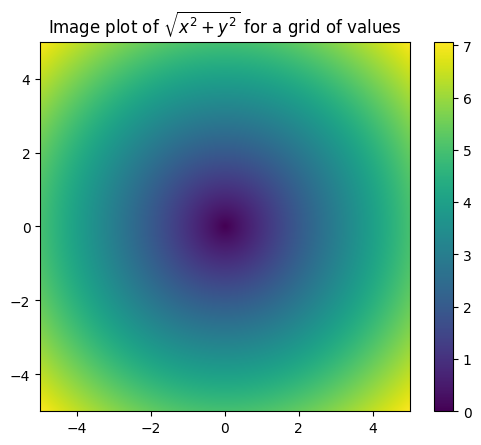

In [342]:
# Visualise data
## Note the imperative nature of functions...
import matplotlib.pyplot as plt

plt.imshow(out, extent=[-5, 5, -5, 5])
plt.colorbar()
plt.title("Image plot of $\sqrt{x^2 + y^2}$ for a grid of values")

### Expressing Conditional Logic as Array Operations

Use the `numpy.where` function to extract values from one array if the corresponding boolean array element is `True`, and another if the element is `False`.

In [343]:
# Create array
arr = np.random.standard_normal((2, 3, 4))
arr

array([[[ 0.03032373,  0.48009507,  0.7889652 ,  0.45781743],
        [ 0.641243  , -2.22569258, -0.55851959,  0.10580836],
        [ 0.97280063,  1.62656036, -3.31777144, -2.08051669]],

       [[ 2.85218094, -0.30466623,  0.61382222, -0.06103806],
        [-2.85283893, -0.47683936, -0.72592743,  0.28002   ],
        [ 1.22020623,  1.49087702, -0.58856378,  1.09779914]]])

In [344]:
# Boolean array representing positive values
arr > 0

# Use boolean array to select values from original array
# Keep as is if value is positive
# Multiply with -1 if negative
np.where(arr > 0, arr, -1 * arr)

array([[[0.03032373, 0.48009507, 0.7889652 , 0.45781743],
        [0.641243  , 2.22569258, 0.55851959, 0.10580836],
        [0.97280063, 1.62656036, 3.31777144, 2.08051669]],

       [[2.85218094, 0.30466623, 0.61382222, 0.06103806],
        [2.85283893, 0.47683936, 0.72592743, 0.28002   ],
        [1.22020623, 1.49087702, 0.58856378, 1.09779914]]])

Either array can be replaced with a scalar.

In [345]:
# Use boolean array to select values from original array
# Keep as is if value is negative
# Replace with 0 if positive
np.where(arr < 0, arr, 0)

array([[[ 0.        ,  0.        ,  0.        ,  0.        ],
        [ 0.        , -2.22569258, -0.55851959,  0.        ],
        [ 0.        ,  0.        , -3.31777144, -2.08051669]],

       [[ 0.        , -0.30466623,  0.        , -0.06103806],
        [-2.85283893, -0.47683936, -0.72592743,  0.        ],
        [ 0.        ,  0.        , -0.58856378,  0.        ]]])

### Mathematical and Statistical Methods

The `ndarray` class has methods that facilitate mathematical and statistical summarisations of the array. Access as a method or as a function.

In [346]:
# Example array (2 x 4)
arr = np.random.standard_normal((2, 4))
arr

array([[-1.06116217, -0.08423788,  0.55749573,  0.20567772],
       [ 1.06122281, -1.22637429,  0.33256009,  0.11431274]])

In [347]:
# Get sum of array
## As method
arr.sum()
## As function
np.sum(arr)

np.float64(-0.10050524325572857)

Some methods can calculate across a desired dimension.

In [348]:
# Compute across dim 1 (columns)
arr.sum(1)

# Compute across dim 0 (rows)
arr.sum(0)

array([ 6.06446666e-05, -1.31061217e+00,  8.90055821e-01,  3.19990459e-01])

### Methods for Boolean Arrays

Boolean values are coerced to 1 and 0 for NumPy methods.

In [349]:
# Example array
arr

array([[-1.06116217, -0.08423788,  0.55749573,  0.20567772],
       [ 1.06122281, -1.22637429,  0.33256009,  0.11431274]])

In [350]:
# Boolean array showing positive values
arr > 0

array([[False, False,  True,  True],
       [ True, False,  True,  True]])

In [351]:
# Count of positive values (counts of True in the above boolean array)
(arr > 0).sum()

np.int64(5)

### Sorting

The `sort` method can sort arrays in place. Call this as a function to not mutate the array.

In [352]:
# Example array
arr = np.random.standard_normal((2, 3, 4))
arr

array([[[-1.52777602,  0.62979886, -2.35106927,  2.12450773],
        [ 0.2413567 , -0.18193709,  0.67761768,  0.15768789],
        [-1.77468403, -1.96414257,  1.24232348,  0.34084665]],

       [[ 0.33374053,  0.54111197,  0.03705091,  0.51025153],
        [ 0.03310783,  0.66631404, -0.03149115, -0.81720025],
        [-0.80483808, -0.97050999,  0.18345118, -0.78979054]]])

In [353]:
# Get sorted view, leave array alone
np.sort(arr)

array([[[-2.35106927, -1.52777602,  0.62979886,  2.12450773],
        [-0.18193709,  0.15768789,  0.2413567 ,  0.67761768],
        [-1.96414257, -1.77468403,  0.34084665,  1.24232348]],

       [[ 0.03705091,  0.33374053,  0.51025153,  0.54111197],
        [-0.81720025, -0.03149115,  0.03310783,  0.66631404],
        [-0.97050999, -0.80483808, -0.78979054,  0.18345118]]])

In [354]:
# Array unchanged
arr

array([[[-1.52777602,  0.62979886, -2.35106927,  2.12450773],
        [ 0.2413567 , -0.18193709,  0.67761768,  0.15768789],
        [-1.77468403, -1.96414257,  1.24232348,  0.34084665]],

       [[ 0.33374053,  0.54111197,  0.03705091,  0.51025153],
        [ 0.03310783,  0.66631404, -0.03149115, -0.81720025],
        [-0.80483808, -0.97050999,  0.18345118, -0.78979054]]])

In [355]:
# Sort array in place
arr.sort()
arr

array([[[-2.35106927, -1.52777602,  0.62979886,  2.12450773],
        [-0.18193709,  0.15768789,  0.2413567 ,  0.67761768],
        [-1.96414257, -1.77468403,  0.34084665,  1.24232348]],

       [[ 0.03705091,  0.33374053,  0.51025153,  0.54111197],
        [-0.81720025, -0.03149115,  0.03310783,  0.66631404],
        [-0.97050999, -0.80483808, -0.78979054,  0.18345118]]])

The `sort` method can sort across the selected dimensions.

In [356]:
arr = np.random.standard_normal((2, 4))
arr

array([[ 0.06522456, -0.08517747, -0.25058838,  0.99040668],
       [-0.29061807,  1.55604158,  1.91177183, -0.1078368 ]])

In [357]:
# Sort within columns
np.sort(arr, axis=0)

array([[-0.29061807, -0.08517747, -0.25058838, -0.1078368 ],
       [ 0.06522456,  1.55604158,  1.91177183,  0.99040668]])

In [358]:
# Sort within rows
np.sort(arr, axis=1)

array([[-0.25058838, -0.08517747,  0.06522456,  0.99040668],
       [-0.29061807, -0.1078368 ,  1.55604158,  1.91177183]])

## Example: Random Walks

Compare how a random walk can be done using Python functions vs. NumPy. For each step, the walk will add 1, or subtract 1.

In Python, this can be done with a loop.

In [359]:
# Define vars
nsteps = 1000

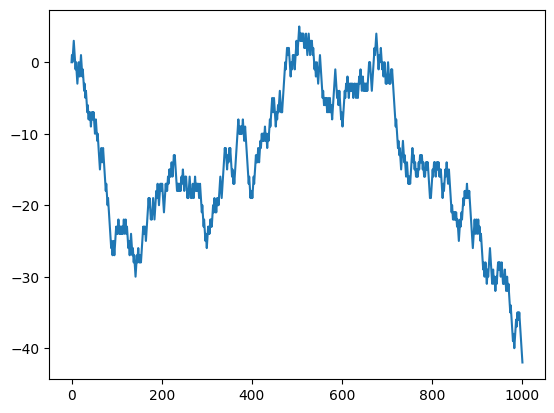

In [360]:
# Python only
import random
position = 0
walk = [position]

## Run
for i in range(nsteps):
    step = random.randint(0, 1)
    if step == 0:
        step = -1
    position = position + step
    walk.append(position)

plt.plot(walk)

With NumPy, we can:
- Initialize a 1D array of desired length, containing only -1 or 1
- Calculate the cumulative sum across array

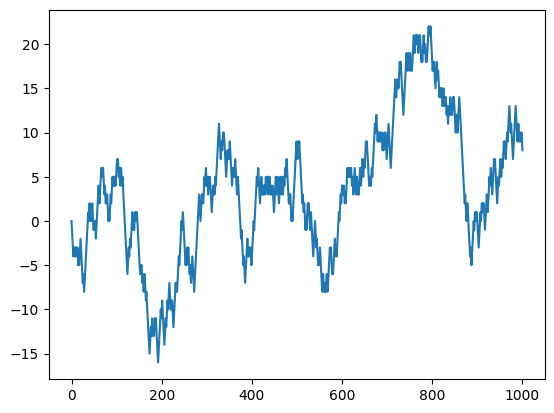

In [361]:
# NumPy
## Create array representing random walk steps
draws = np.random.randint(0, 2, 1000)
draws = np.where(draws == 0, -1, 1)

## Add starting position
walk = np.insert(draws, 0, 0)

## Calculate random walk
walk = np.cumsum(walk)
plt.plot(walk)

### Simulating Many Random Walks at Once

To do so, we begin with a 2-tuple representing both number of walks and walk length.

Dim 1 could represent the walk number (Sample) and Dim 2 represent walk step (Observation).

In [362]:
# Define variables
nwalks = 5000
nsteps = 1000

## Create array representing random walk steps
draws = np.random.randint(0, 2, size = (nwalks, nsteps))
draws = np.where(draws == 0, -1, 1)

## Add starting position to start of each walk in dim 1
walks = np.insert(draws, 0, 0, axis = 1)

## Calculate random walk (across dim 1)
walks = np.cumsum(walks, axis = 1)
walks

array([[  0,   1,   0, ...,   8,   7,   6],
       [  0,   1,   0, ...,   8,   9,   8],
       [  0,  -1,   0, ...,  34,  35,  34],
       ...,
       [  0,   1,   2, ..., -22, -23, -22],
       [  0,  -1,  -2, ..., -32, -33, -34],
       [  0,  -1,  -2, ...,   4,   5,   6]], shape=(5000, 1001))

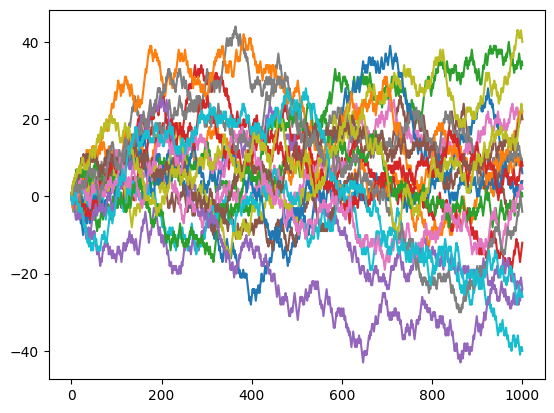

In [363]:
# Plot a selection of walks
# First 20 walks
plt.plot(walks[:20].T)

(array([1632.,  305.,  487.,  505.,  448.,  411.,  386.,  352.,  242.,  232.]),
 array([   0.,  100.,  200.,  300.,  400.,  500.,  600.,  700.,  800.,  900., 1000.]),
 <BarContainer object of 10 artists>)

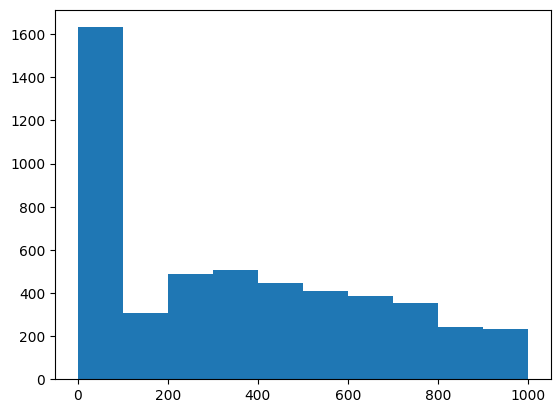

In [364]:
# Profile walks
## Get minimum crossing time to 30 or -30
## Method:
## Get boolean array showing which array values are above 30 / below - 30
## Use argmax to get the index of the first instance where the boolean is True

## Get boolean array
arr_bool = np.abs(walks) >= 30

## Get index of first instance
cross_time = arr_bool.argmax(axis = 1)

## Plot histogram (excluding 0s)
plt.hist(cross_time)